In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import pandas as pd

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

## 버스, 따릉이, 지하철 데이터 로드 및 좌표 변환

In [13]:
# 버스정류장 데이터 로드
df_bus = pd.read_csv("서울시 버스정류소 위치정보.csv", encoding='cp949')
df_bus = df_bus.rename(columns = {"X좌표": "경도", "Y좌표": "위도"})
display(df_bus.head())

# 좌표를 Point로 변환
# SGIS 행정동 경계 좌표계 UTM-K(GRS80타원체)는 crs: EPSG:5179
df_bus["geometry"] = df_bus.apply(lambda x: Point(x["경도"], x["위도"]), axis = 1)
geo_bus = GeoDataFrame(df_bus, crs = "EPSG:5179", geometry = "geometry")
display(geo_bus.head())

,노드 ID,정류소번호,정류소명,경도,위도,정류소 타입
0,100000001,1001,종로2가사거리,126.987752,37.569808,중앙차로
1,100000002,1002,창경궁.서울대학교병원,126.996522,37.579433,중앙차로
2,100000003,1003,명륜3가.성대입구,126.998251,37.582581,중앙차로
3,100000004,1004,종로2가.삼일교,126.987613,37.568579,중앙차로
4,100000005,1005,혜화동로터리.여운형활동터,127.001744,37.586243,중앙차로


,노드 ID,정류소번호,정류소명,경도,위도,정류소 타입,geometry
0,100000001,1001,종로2가사거리,126.987752,37.569808,중앙차로,POINT (126.988 37.57)
1,100000002,1002,창경궁.서울대학교병원,126.996522,37.579433,중앙차로,POINT (126.997 37.579)
2,100000003,1003,명륜3가.성대입구,126.998251,37.582581,중앙차로,POINT (126.998 37.583)
3,100000004,1004,종로2가.삼일교,126.987613,37.568579,중앙차로,POINT (126.988 37.569)
4,100000005,1005,혜화동로터리.여운형활동터,127.001744,37.586243,중앙차로,POINT (127.002 37.586)


In [14]:
# 따릉이대여소 데이터 로드
df_bike = pd.read_csv("서울시 따릉이대여소 마스터 정보.csv", encoding='cp949')
df_bike = df_bike[df_bike['위도']!=0]
df_bike = df_bike.rename(columns = {"X좌표": "경도", "Y좌표": "위도"})
display(df_bike.head())

# 좌표를 Point로 변환
# SGIS 행정동 경계 좌표계 UTM-K(GRS80타원체)는 crs: EPSG:5179
df_bike["geometry"] = df_bike.apply(lambda x: Point(x["경도"], x["위도"]), axis = 1)
geo_bike = GeoDataFrame(df_bike, crs = "EPSG:5179", geometry = "geometry")
display(geo_bike.head())

,대여소_ID,주소1,주소2,위도,경도
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323
5,ST-994,서울특별시 양천구 목동서로161,SBS방송국,37.529163,126.872749
6,ST-993,서울특별시 양천구 신월로 342-1 구두수선대19,NaN,37.521511,126.857384


,대여소_ID,주소1,주소2,위도,경도,geometry
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598,POINT (126.87 37.534)
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548,POINT (126.851 37.524)
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323,POINT (126.857 37.511)
5,ST-994,서울특별시 양천구 목동서로161,SBS방송국,37.529163,126.872749,POINT (126.873 37.529)
6,ST-993,서울특별시 양천구 신월로 342-1 구두수선대19,NaN,37.521511,126.857384,POINT (126.857 37.522)


In [15]:
# 지하철 데이터 로드
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding='cp949')
df_metro = df_metro.rename(columns = {"X좌표": "경도", "Y좌표": "위도"})
display(df_metro.head())

# 좌표를 Point로 변환
# SGIS 행정동 경계 좌표계 UTM-K(GRS80타원체)는 crs: EPSG:5179
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis = 1)
geo_metro = GeoDataFrame(df_metro, crs = "EPSG:5179", geometry = "geometry")
display(geo_metro.head()) 

,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569
1,9009,구성,수도권 광역급행철도,37.29913,127.10389
2,9008,성남,수도권 광역급행철도,37.39467,127.12058
3,9007,수서,수도권 광역급행철도,37.48637,127.10161
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324


,역사_ID,역사명,호선,위도,경도,geometry
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569,POINT (127.096 37.2)
1,9009,구성,수도권 광역급행철도,37.29913,127.10389,POINT (127.104 37.299)
2,9008,성남,수도권 광역급행철도,37.39467,127.12058,POINT (127.121 37.395)
3,9007,수서,수도권 광역급행철도,37.48637,127.10161,POINT (127.102 37.486)
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324,POINT (127.063 37.509)


## 서울 500m 격자 불러오기 

In [16]:
geo_shp = gpd.read_file("seoul_grid_500m.shp")

print(f"파일 로드 후 초기 좌표계: {geo_shp.crs}")
print(geo_shp.head())

파일 로드 후 초기 좌표계: EPSG:4326
            cx           cy                                           geometry
0  179439.7616  450297.4067  POLYGON ((126.7645 37.54971, 126.76449 37.5542...
1  179439.7616  450797.4067  POLYGON ((126.76449 37.55422, 126.76447 37.558...
2  179939.7616  449797.4067  POLYGON ((126.77017 37.54522, 126.77016 37.549...
3  179939.7616  450297.4067  POLYGON ((126.77016 37.54972, 126.77015 37.554...
4  179939.7616  450797.4067  POLYGON ((126.77015 37.55423, 126.77013 37.558...


## 경사값 가져오기

In [38]:
slope_shp = gpd.read_file("slope_seoul.shp")

print(f"파일 로드 후 초기 좌표계: {slope_shp.crs}")
slope_shp.head()

파일 로드 후 초기 좌표계: EPSG:4326


,cx,cy,slope_mean,geometry
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542..."
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558..."
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549..."
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554..."
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558..."


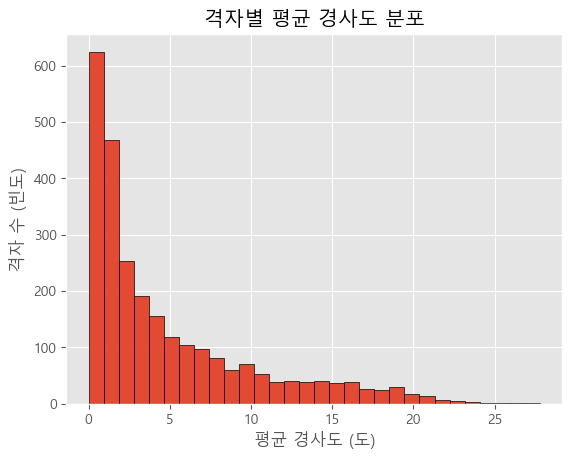

In [36]:
import matplotlib.pyplot as plt

# Matplotlib의 스타일을 지정하면 더 깔끔해집니다.
plt.style.use('ggplot')

slope_shp['slope_mean'].hist(bins=30, edgecolor='black')

plt.title('격자별 평균 경사도 분포')
plt.xlabel('평균 경사도 (도)')
plt.ylabel('격자 수 (빈도)')
plt.show()

## 격자에 각 정류장/역 수 count (반경 500m <=> 1격자로 통일)

In [18]:
bus = gpd.sjoin(geo_bus, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
bus_counts_per_grid = bus.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
bus_counts_df = bus_counts_per_grid.to_frame('bus_count').reset_index()

print("--- 격자별 버스정류소 개수 ---")
print(bus_counts_df.head())

--- 격자별 버스정류소 개수 ---
   index_right  bus_count
0            1          2
1           32          2
2           41          2
3           42          1
4           52         11


C:\Users\Mycom\AppData\Local\Temp\ipykernel_20768\287754335.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:5179
Right CRS: EPSG:4326

  bus = gpd.sjoin(geo_bus, geo_shp)


In [19]:
bike = gpd.sjoin(geo_bike, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
bike_counts_per_grid = bike.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
bike_counts_df = bike_counts_per_grid.to_frame('bike_count').reset_index()

print("--- 격자별 따릉이 정류소 개수 ---")
print(bike_counts_df.head())

--- 격자별 따릉이 정류소 개수 ---
   index_right  bike_count
0           41           1
1           56           1
2           57           1
3           66           1
4           67           2


C:\Users\Mycom\AppData\Local\Temp\ipykernel_20768\4105275201.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:5179
Right CRS: EPSG:4326

  bike = gpd.sjoin(geo_bike, geo_shp)


In [42]:
metro = gpd.sjoin(geo_metro, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
metro_counts_per_grid = metro.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
metro_counts_df = metro_counts_per_grid.to_frame('metro_count').reset_index()

print("--- 격자별 따릉이 정류소 개수 ---")
print(metro_counts_df.head())

--- 격자별 따릉이 정류소 개수 ---
   index_right  metro_count
0           41            1
1           52            4
2           67            1
3           70            1
4           86            1


C:\Users\Mycom\AppData\Local\Temp\ipykernel_20768\2658088347.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:5179
Right CRS: EPSG:4326

  metro = gpd.sjoin(geo_metro, geo_shp)


In [45]:
slope_shp

,cx,cy,slope_mean,geometry
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542..."
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558..."
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549..."
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554..."
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558..."
...,...,...,...,...
2634,215939.7616,451297.4067,0.933832,"POLYGON ((127.17757 37.55882, 127.17758 37.563..."
2635,215939.7616,451797.4067,0.526118,"POLYGON ((127.17758 37.56333, 127.1776 37.5678..."
2636,215939.7616,452297.4067,0.654032,"POLYGON ((127.1776 37.56783, 127.17761 37.5723..."
2637,216439.7616,449297.4067,19.669617,"POLYGON ((127.18319 37.54079, 127.1832 37.5453..."


In [21]:
slope = gpd.sjoin(slope_shp, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
slope_counts_per_grid = slope.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
slope_counts_df = slope_counts_per_grid.to_frame('slope_count').reset_index()

print("--- 격자별 slope 개수 ---")
print(slope_counts_df.head())

--- 격자별 slope 개수 ---
   index_right  slope_count
0            0            4
1            1            4
2            2            5
3            3            7
4            4            7


In [72]:
# 원본 격자 데이터(geo_shp)와 버스 개수 데이터(bus_counts_df)를 합칩니다.
# 1. 버스 개수 합치기
grid_with_counts = geo_shp.merge(bus_counts_df, left_on=geo_shp.index, right_on='index_right', how='left')
# 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 2. 자전거(따릉이) 개수 합치기
grid_with_counts = grid_with_counts.merge(bike_counts_df, left_on=grid_with_counts.index, right_on='index_right', how='left')
# 다시 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 3. 지하철 개수 합치기
grid_with_counts = grid_with_counts.merge(metro_counts_df, left_on=grid_with_counts.index, right_on='index_right', how='left')
# 마지막으로 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 4. 슬로프 개수 합치기 
grid_with_counts = grid_with_counts.merge(slope_counts_df, left_on=grid_with_counts.index, right_on='index_right', how='left')
# 마지막으로 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 4. (마무리) 새로 생긴 모든 count 컬럼의 NaN 값을 0으로 채우기
count_columns = ['bus_count', 'bike_count', 'metro_count', 'slope_count'] # 실제 컬럼 이름으로 변경해야 합니다.
grid_with_counts[count_columns] = grid_with_counts[count_columns].fillna(0)

grid_with_counts['total_count'] = grid_with_counts[count_columns].sum(axis=1)
grid_with_counts['slope_bike_count'] = grid_with_counts['bike_count']/grid_with_counts['slope_count']


print("\n--- 버스 개수 정보가 합쳐진 최종 격자 데이터 ---")
(grid_with_counts.head())



--- 버스 개수 정보가 합쳐진 최종 격자 데이터 ---


,cx,cy,geometry,bus_count,bike_count,metro_count,slope_count,total_count,slope_bike_count
0,179439.7616,450297.4067,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.0,0.0,0.0,4,4.0,0.0
1,179439.7616,450797.4067,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",2.0,0.0,0.0,4,6.0,0.0
2,179939.7616,449797.4067,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.0,0.0,0.0,5,5.0,0.0
3,179939.7616,450297.4067,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.0,0.0,0.0,7,7.0,0.0
4,179939.7616,450797.4067,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.0,0.0,0.0,7,7.0,0.0


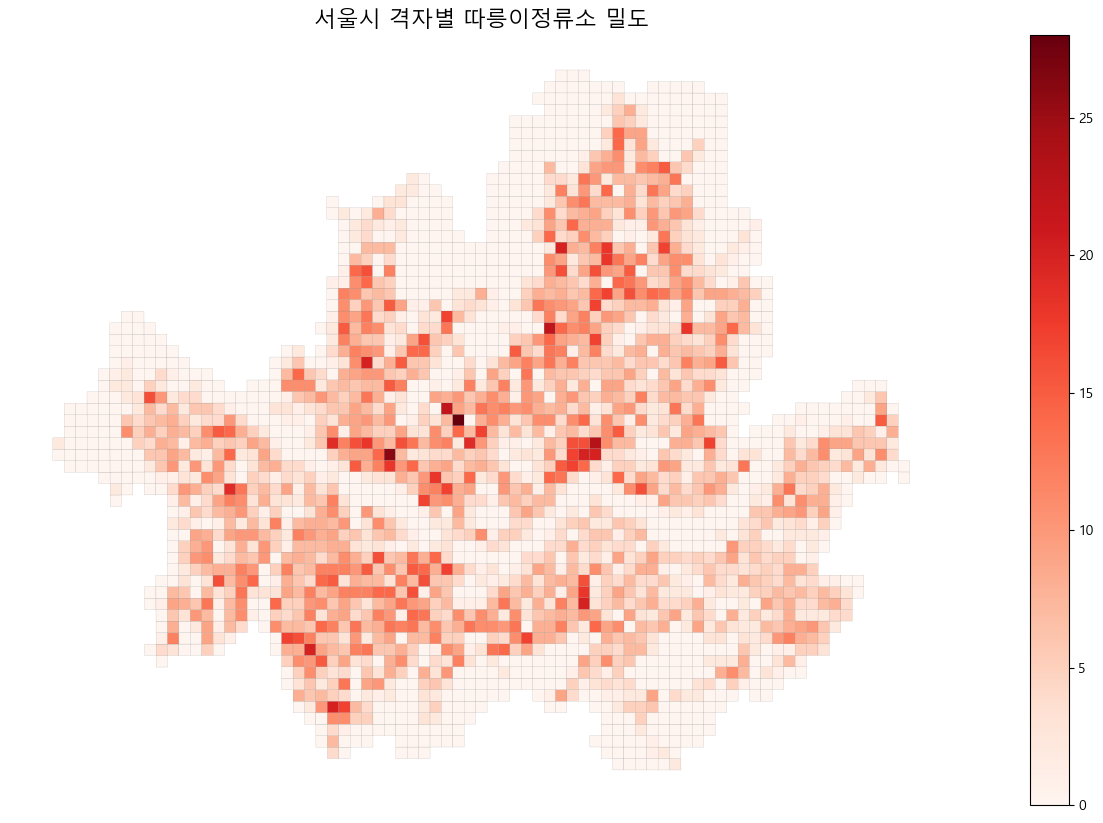

In [100]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='bus_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 따릉이정류소 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

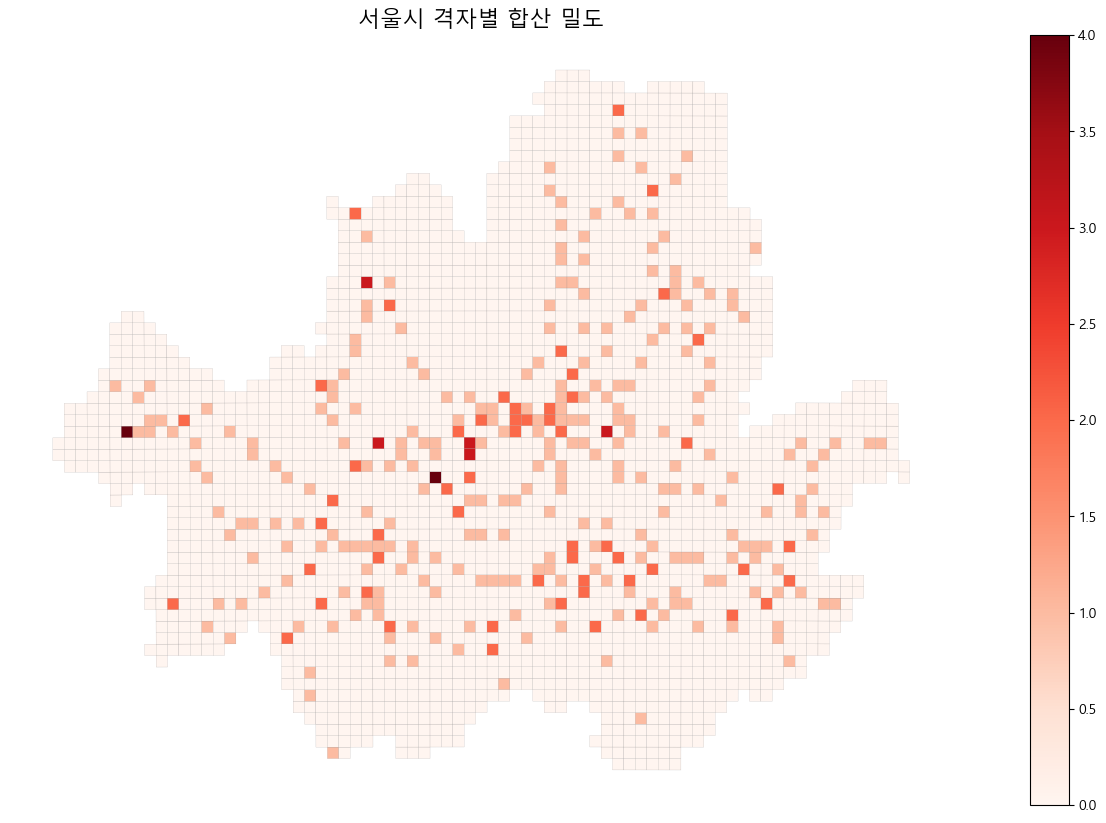

In [101]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='metro_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 합산 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

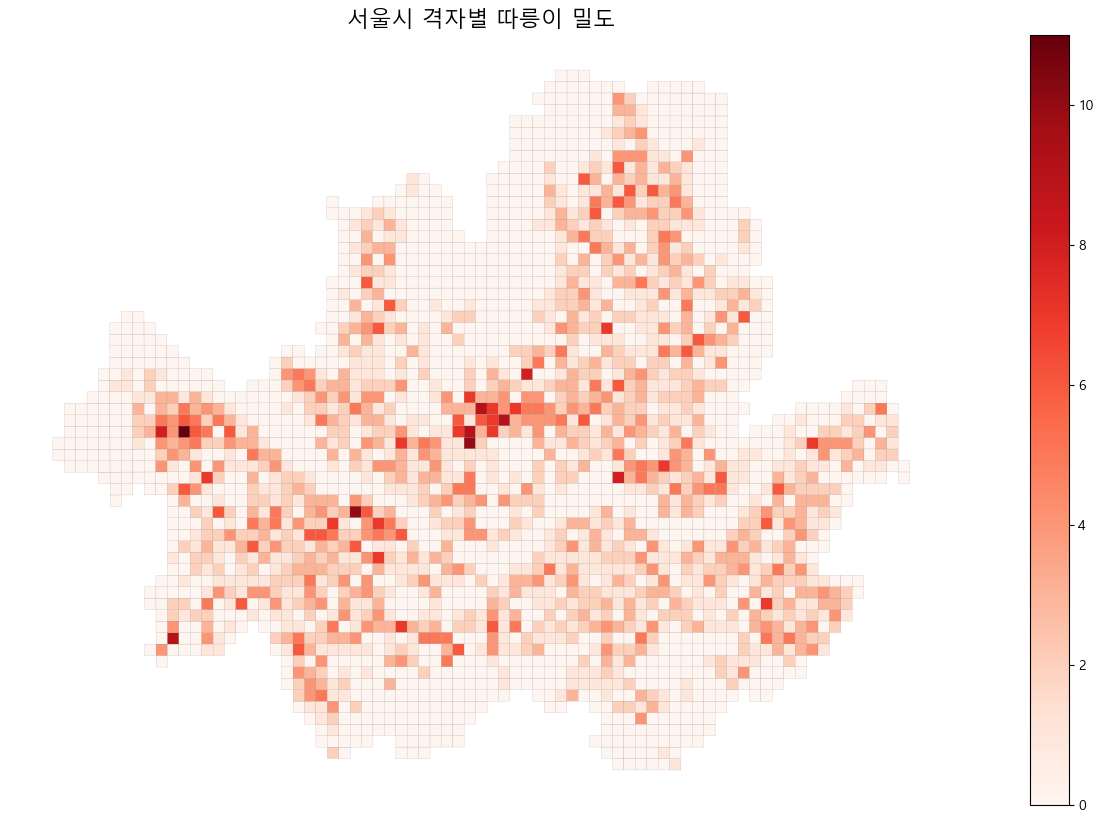

In [27]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='bike_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 따릉이 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

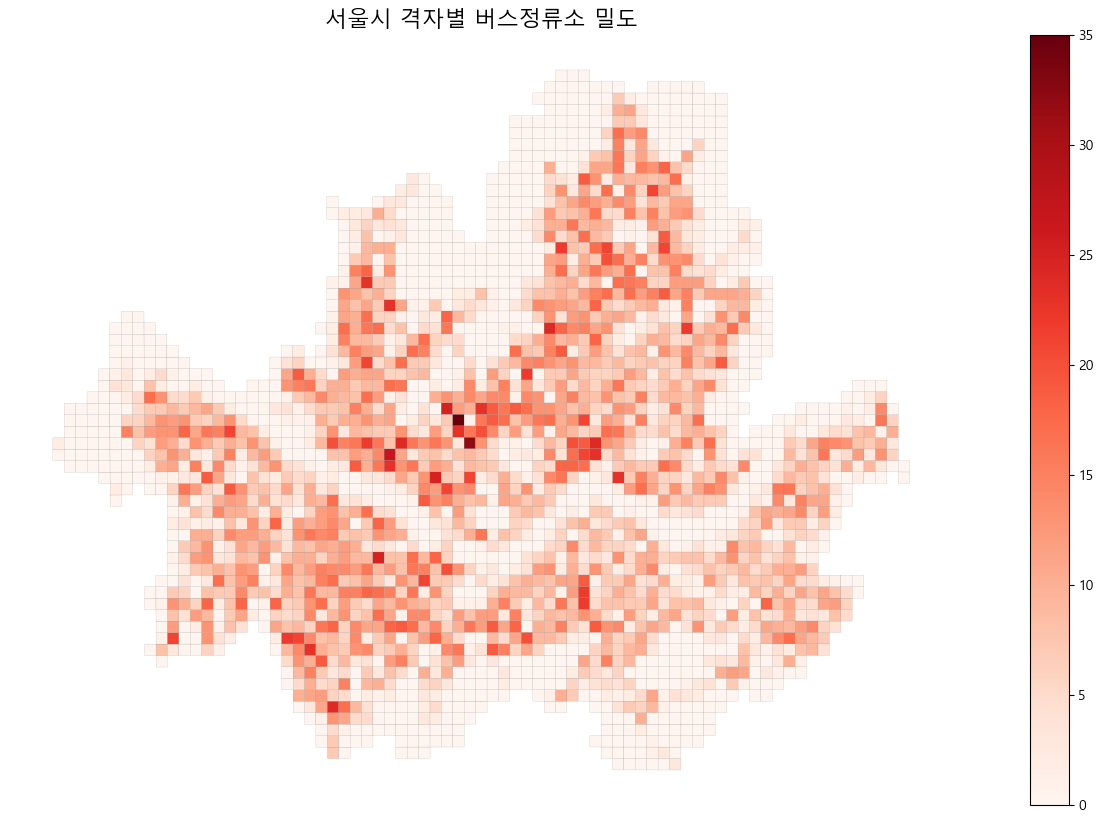

In [95]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='total_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 버스정류소 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

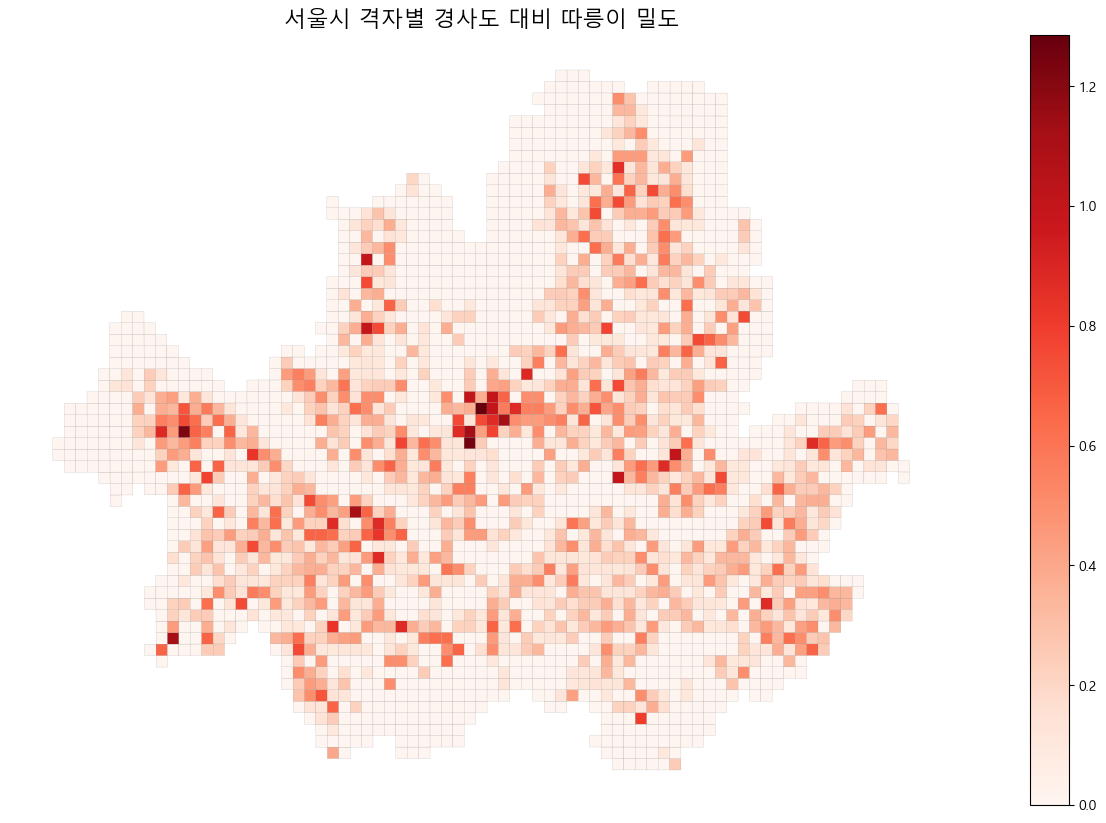

In [26]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='slope_bike_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 경사도 대비 따릉이 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

## slope 적용

In [67]:
slope_shp['slope_mean'].describe()

count    2639.000000
mean        4.868649
std         5.239078
min         0.016756
25%         1.006176
50%         2.708179
75%         7.106035
max        27.785015
Name: slope_mean, dtype: float64

In [56]:
# 원본 격자 데이터(경사도 정보 포함)를 복사하여 사용합니다.
# 'geo_shp'에 slope_mean과 geometry가 모두 있다고 가정합니다.
final_grid = slope_shp.copy()

# 1. 버스 개수 합치기
final_grid = final_grid.merge(bus_counts_df, left_on=final_grid.index, right_on='index_right', how='left')
final_grid = final_grid.drop('index_right', axis=1) # 불필요한 열 삭제

# 2. 따릉이 개수 합치기
final_grid = final_grid.merge(bike_counts_df, left_on=final_grid.index, right_on='index_right', how='left')
final_grid = final_grid.drop('index_right', axis=1)

# 3. 지하철 개수 합치기
final_grid = final_grid.merge(metro_counts_df, left_on=final_grid.index, right_on='index_right', how='left')
final_grid = final_grid.drop('index_right', axis=1)

# 4. 개수가 없는 격자(NaN)는 0으로 채우기
count_cols = ['bus_count', 'bike_count', 'metro_count']
final_grid[count_cols] = final_grid[count_cols].fillna(0)

print("--- 모든 개수 정보가 통합된 데이터 ---")
final_grid.head()

--- 모든 개수 정보가 통합된 데이터 ---


,cx,cy,slope_mean,geometry,bus_count,bike_count,metro_count
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.0,0.0,0.0
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",2.0,0.0,0.0
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.0,0.0,0.0
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.0,0.0,0.0
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.0,0.0,0.0


In [68]:
import numpy as np

# 경사도에 따른 페널티 가중치(등급)를 정의합니다.
conditions = [
    (final_grid['slope_mean'] <= 3),  # 평지
    (final_grid['slope_mean'] > 3) & (final_grid['slope_mean'] <= 7),  # 완경사
    (final_grid['slope_mean'] > 7)   # 급경사
]
# 평지는 100% 가치, 완경사는 60%, 급경사는 20%의 가치만 인정
weights = [1.0, 0.6, 0.2]

# 'slope_weight' 컬럼에 각 격자의 경사도 가중치를 할당
final_grid['slope_weight'] = np.select(conditions, weights, default=0)

# '조정된 따릉이 점수' = (기존 따릉이 개수) * (경사도 가중치)
final_grid['adjusted_bike_score'] = final_grid['bike_count'] * final_grid['slope_weight']

print("\n--- 경사도가 반영된 따릉이 점수 ---")
final_grid.head()


--- 경사도가 반영된 따릉이 점수 ---


,cx,cy,slope_mean,geometry,bus_count,bike_count,metro_count,slope_weight,adjusted_bike_score,transport_score,transport_score_normalized
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.0,0.0,0.0,0.2,0.0,0.0,0.000000
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",2.0,0.0,0.0,0.2,0.0,2.0,6.153846
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.0,0.0,0.0,1.0,0.0,0.0,0.000000
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.0,0.0,0.0,1.0,0.0,0.0,0.000000
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.0,0.0,0.0,1.0,0.0,0.0,0.000000


In [81]:
# 각 교통수단별 중요도(가중치) 설정 (예시)
w_metro = 1  # 지하철은 가장 중요하므로 1.5점
w_bus = 1    # 버스는 기본 점수인 1.0점
w_bike = 1   # 따릉이는 보조 수단이므로 0.5점

# 최종 교통 편의성 지수 계산
final_grid['transport_score'] = (final_grid['metro_count'] * w_metro) + \
                                (final_grid['bus_count'] * w_bus) + \
                                (final_grid['adjusted_bike_score'] * w_bike) # 조정된 따릉이 점수 사용!

# (선택) 점수를 0~100점으로 정규화하여 비교하기 쉽게 만들기
score = final_grid['transport_score']
#final_grid['transport_score_normalized'] = ((score - score.min()) / (score.max() - score.min())) * 100

print("\n--- 최종 교통 편의성 지수 ---")
final_grid.sort_values(by='transport_score', ascending=False).head()


--- 최종 교통 편의성 지수 ---


,cx,cy,slope_mean,geometry,bus_count,bike_count,metro_count,slope_weight,adjusted_bike_score,transport_score,transport_score_normalized
1044,196939.7616,451797.4067,2.289701,"POLYGON ((126.96253 37.56345, 126.96253 37.567...",28.0,6.0,1.0,1.0,6.0,35.0,100.000000
1085,197439.7616,450797.4067,1.398776,"POLYGON ((126.9682 37.55445, 126.96819 37.5589...",19.0,10.0,3.0,1.0,10.0,32.0,87.692308
744,193939.7616,450297.4067,5.995217,"POLYGON ((126.92859 37.54992, 126.92859 37.554...",26.0,1.0,0.0,0.6,0.6,26.6,80.923077
688,193439.7616,445797.4067,2.192722,"POLYGON ((126.92297 37.50937, 126.92297 37.513...",16.0,7.0,2.0,1.0,7.0,25.0,69.230769
491,191439.7616,439297.4067,1.085761,"POLYGON ((126.90043 37.45079, 126.90042 37.455...",20.0,4.0,0.0,1.0,4.0,24.0,67.692308


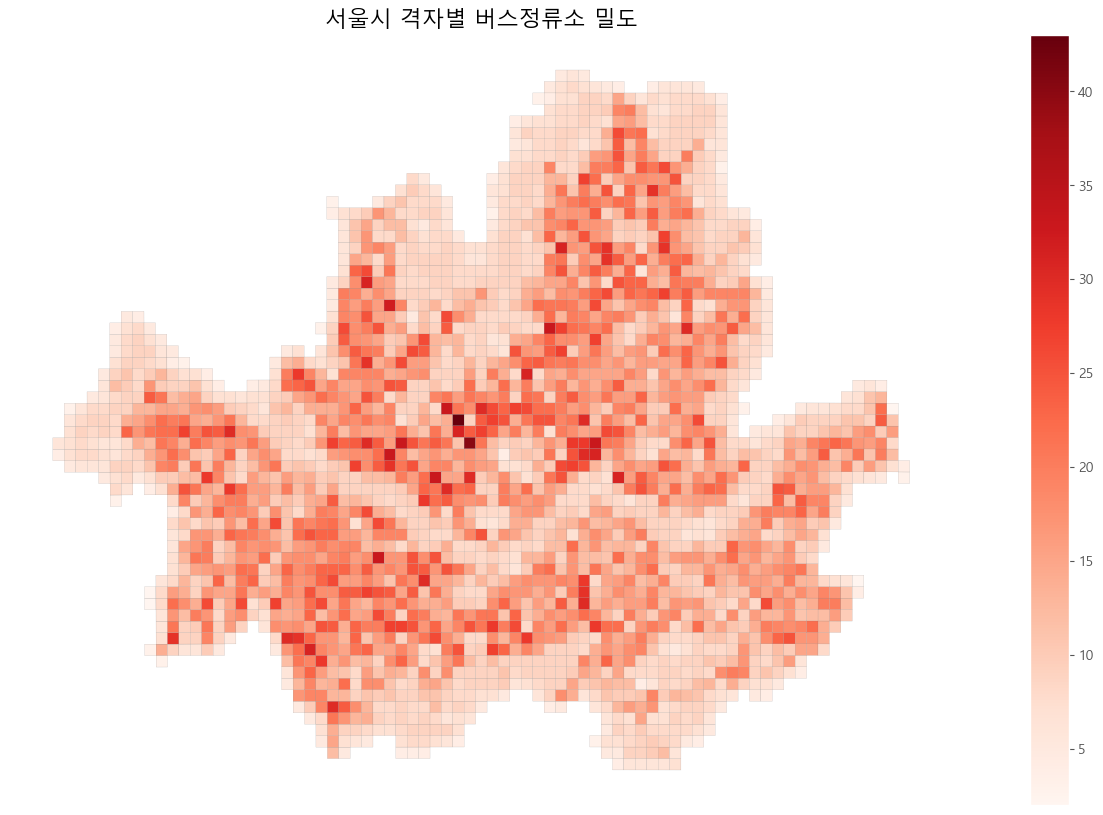

In [73]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='total_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 버스정류소 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

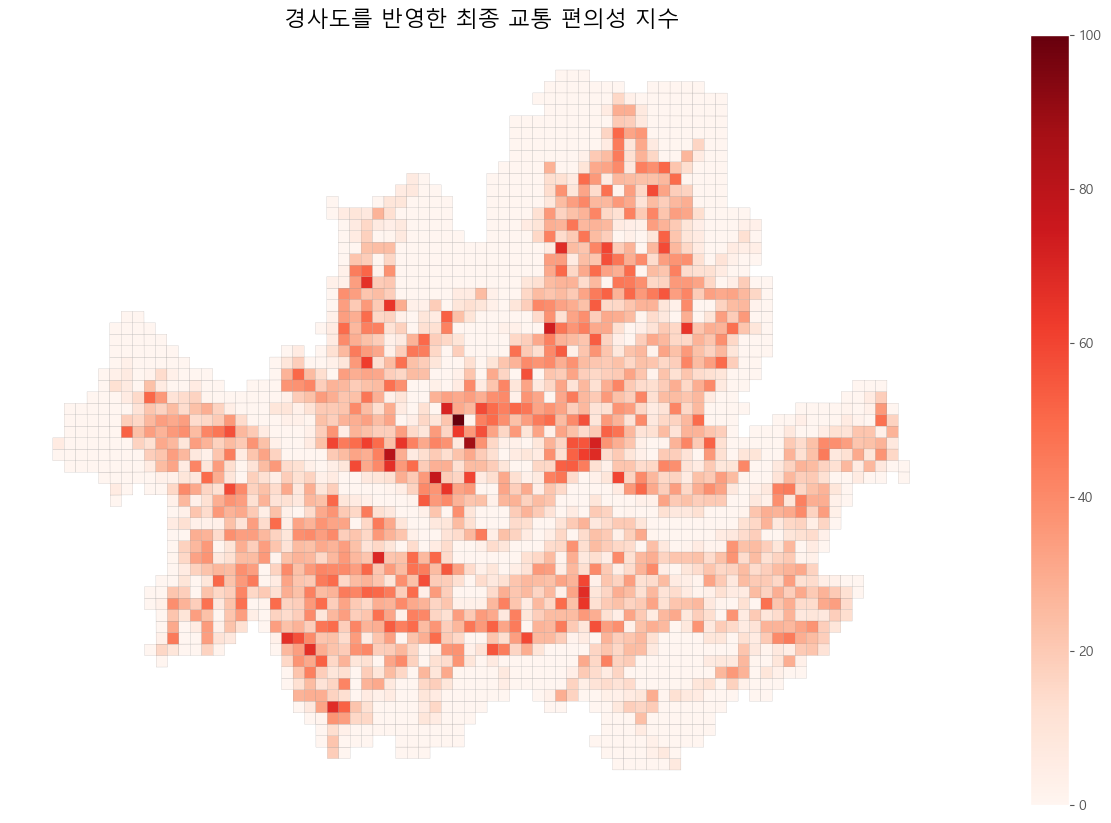

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(20, 10))

final_grid.plot(column='transport_score_normalized', # 정규화된 점수 사용
                cmap='Reds',
                linewidth=0.1,
                edgecolor='grey',
                legend=True,
                ax=ax)

ax.set_title('경사도를 반영한 최종 교통 편의성 지수', fontsize=16)
ax.set_axis_off()
plt.show()

## 시각화

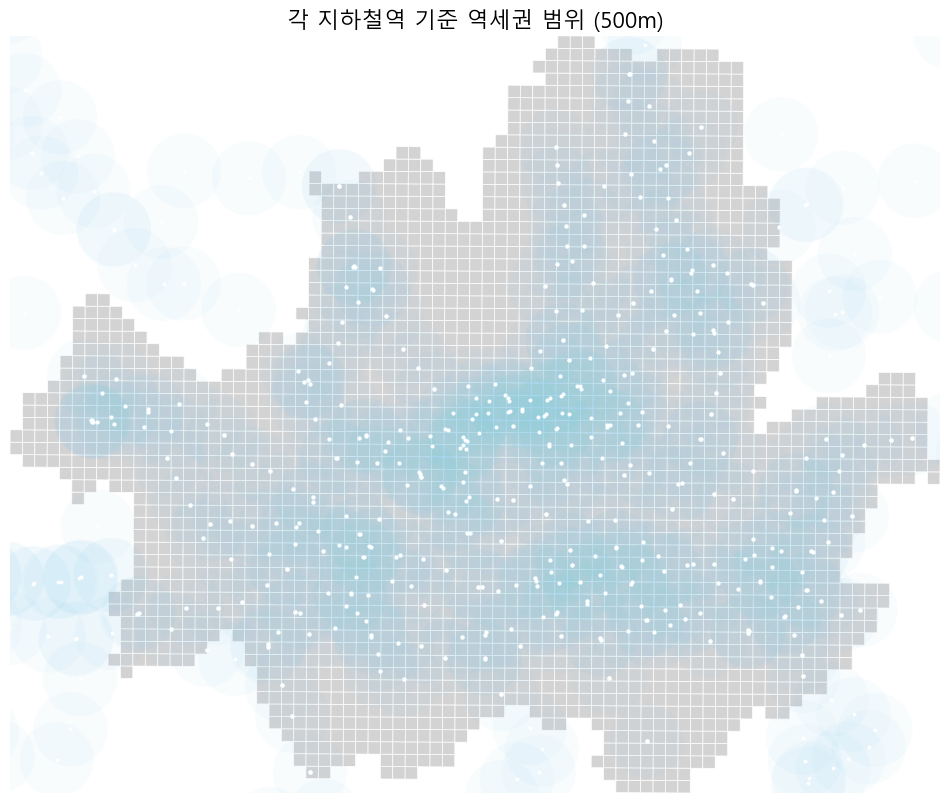

In [140]:
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- 1. 격자(shp) 데이터 처리 ---
# shp 파일을 불러옵니다. (이때 geometry는 위경도가 맞습니다. CRS: EPSG:4326)
geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")

# !!! 가장 중요한 수정 부분 !!!
# 분석을 위해 격자 데이터를 미터 좌표계(EPSG:5179)로 '변환'합니다.
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")


# --- 2. 지하철 데이터 처리 ---
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding='cp949')
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)

# 올바른 위경도 좌표계(EPSG:4326)로 '정의'
geo_metro_wgs84 = GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry")

# 지하철 데이터도 격자와 동일한 미터 좌표계(EPSG:5179)로 '변환'합니다.
geo_metro = geo_metro_wgs84.to_crs("EPSG:5179")


# --- 3. 최종 시각화 (수정된 부분) ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 배경 지도 그리기
geo_shp.plot(ax=ax, color='lightgray', edgecolor='white')
geo_metro.plot(ax=ax, marker='o', color='white', markersize=8, label='지하철역')

# --- ↓↓↓ 이 부분을 추가/수정하세요! ↓↓↓ ---
# 1. 각 지하철역(Point)을 기준으로 500m 반경의 원(Polygon)을 생성합니다.
metro_buffers = geo_metro.buffer(1500)

# 2. 생성된 버퍼(원)들을 지도에 그립니다. (반투명 파란색)
# zorder=2를 주어 격자 위에, 점보다는 아래에 위치시킵니다.
metro_buffers.plot(ax=ax, color='skyblue', alpha=0.05, edgecolor='none', label='역세권 (반경 500m)', zorder=2)

# 3. 원본 지하철역 위치(점)를 가장 위에 그립니다. (zorder=3)
geo_metro.plot(ax=ax, marker='o', color='white', markersize=5, zorder=3)
# --- ↑↑↑ 여기까지 추가! ↑↑↑ ---
ax.set_title('각 지하철역 기준 역세권 범위 (500m)', fontsize=16)
ax.set_axis_off()

# 지도의 범위를 서울 격자에 맞춥니다.
minx, miny, maxx, maxy = geo_shp.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.show()

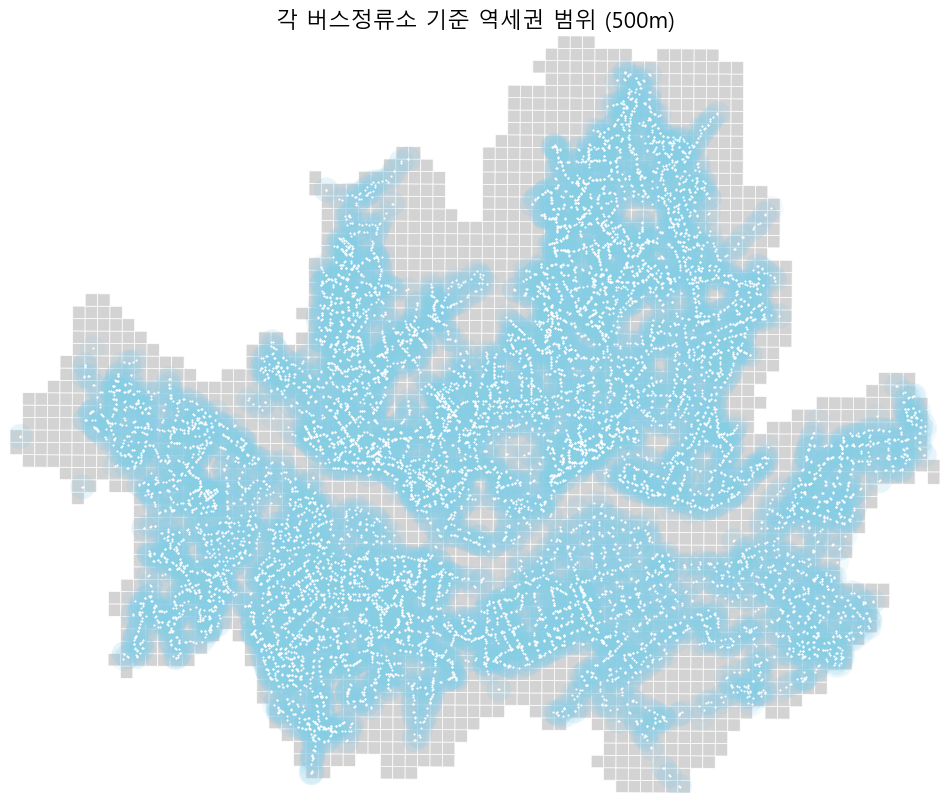

In [142]:
# --- 1, 2단계 코드는 이전과 동일 (데이터 준비) ---
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import matplotlib.pyplot as plt

# 1. 격자(shp) 데이터 처리 (EPSG:5179로 변환)
geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")

# 2. 지하철 데이터 처리 (EPSG:5179로 변환)
df_metro = pd.read_csv("서울시 버스정류소 위치정보.csv", encoding='cp949')
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_metro_wgs84 = GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry")
geo_metro = geo_metro_wgs84.to_crs("EPSG:5179")


# --- 3. 각 지하철역 기준 버퍼 생성 및 시각화 ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 배경 지도로 서울시 격자를 그립니다.
geo_shp.plot(ax=ax, color='lightgray', edgecolor='white', zorder=1)

# --- ↓↓↓ 이 부분을 추가/수정하세요! ↓↓↓ ---
# 1. 각 지하철역(Point)을 기준으로 500m 반경의 원(Polygon)을 생성합니다.
metro_buffers = geo_metro.buffer(500)

# 2. 생성된 버퍼(원)들을 지도에 그립니다. (반투명 파란색)
# zorder=2를 주어 격자 위에, 점보다는 아래에 위치시킵니다.
metro_buffers.plot(ax=ax, color='skyblue', alpha=0.1, edgecolor='none', label='역세권 (반경 500m)', zorder=2)

# 3. 원본 지하철역 위치(점)를 가장 위에 그립니다. (zorder=3)
geo_metro.plot(ax=ax, marker='o', color='white', markersize=1, zorder=3)
# --- ↑↑↑ 여기까지 추가! ↑↑↑ ---

ax.set_title('각 버스정류소 기준 역세권 범위 (500m)', fontsize=16)
ax.set_axis_off()

# 지도의 범위를 서울 격자에 맞춥니다.
minx, miny, maxx, maxy = geo_shp.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.show()

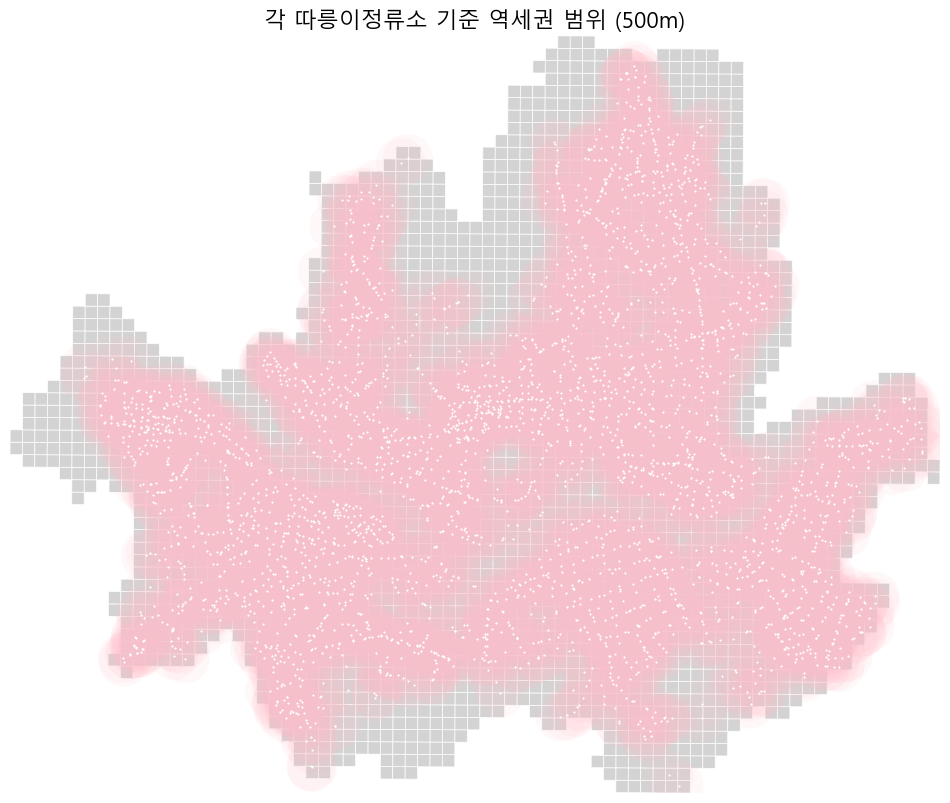

In [141]:
# --- 1, 2단계 코드는 이전과 동일 (데이터 준비) ---
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import matplotlib.pyplot as plt

# 1. 격자(shp) 데이터 처리 (EPSG:5179로 변환)
geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")

# 2. 지하철 데이터 처리 (EPSG:5179로 변환)
df_metro = pd.read_csv("서울시 따릉이대여소 마스터 정보.csv", encoding='cp949')
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_metro_wgs84 = GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry")
geo_metro = geo_metro_wgs84.to_crs("EPSG:5179")


# --- 3. 각 지하철역 기준 버퍼 생성 및 시각화 ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 배경 지도로 서울시 격자를 그립니다.
geo_shp.plot(ax=ax, color='lightgray', edgecolor='white', zorder=1)

# --- ↓↓↓ 이 부분을 추가/수정하세요! ↓↓↓ ---
# 1. 각 지하철역(Point)을 기준으로 500m 반경의 원(Polygon)을 생성합니다.
metro_buffers = geo_metro.buffer(1000)

# 2. 생성된 버퍼(원)들을 지도에 그립니다. (반투명 파란색)
# zorder=2를 주어 격자 위에, 점보다는 아래에 위치시킵니다.
metro_buffers.plot(ax=ax, color='pink', alpha=0.1, edgecolor='none', label='역세권 (반경 500m)', zorder=2)

# 3. 원본 지하철역 위치(점)를 가장 위에 그립니다. (zorder=3)
geo_metro.plot(ax=ax, marker='o', color='white', markersize=1, zorder=3)
# --- ↑↑↑ 여기까지 추가! ↑↑↑ ---

ax.set_title('각 따릉이정류소 기준 역세권 범위 (500m)', fontsize=16)
ax.set_axis_off()

# 지도의 범위를 서울 격자에 맞춥니다.
minx, miny, maxx, maxy = geo_shp.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.show()

# 상권 지수

In [52]:
df

,연도,GU_NM,2023유입인구수,이용금액,20분이상방문자수,방문인구수,정규화된_방문자수,최종점수
0,2024,강남구,27551199.13,57085000,14476207.85,16466971.07,0.579181,1.005933e+08
1,2024,강동구,15429950.81,21137000,0,0,0.000000,3.656695e+07
2,2024,강북구,9940272.65,19891000,315290.5514,279774.7291,0.012531,2.995584e+07
3,2024,강서구,22766816.37,15113000,1719337.476,1204702.321,0.068714,3.944422e+07
4,2024,관악구,32529898.88,11353000,2483488.693,1846958.268,0.099292,4.711286e+07
5,2024,광진구,16447546.17,18547000,0,0,0.000000,3.499455e+07
6,2024,구로구,15568010.17,10596000,2036891.145,2187537.329,0.081421,2.743158e+07
7,2024,금천구,9843962.84,5494000,2446902.595,1827818.057,0.097828,1.630098e+07
8,2024,노원구,16018069.12,45264000,95961.9688,64171.81583,0.003755,6.134222e+07
9,2024,도봉구,9398691.33,26975000,1622705.077,1075431.208,0.064848,3.698317e+07


In [61]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. 파일 읽기 및 결측치 처리
df = pd.read_csv('상권지수(데이터누락).csv', encoding='cp949')
df.replace('-', 0, inplace=True)

# 2. [수정] 계산에 사용할 모든 열을 숫자(numeric) 타입으로 변경
cols_to_numeric = ['20분이상방문자수', '2023유입인구수', '이용금액']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3. [수정] 모든 변수를 0~1 사이의 값으로 '정규화(Normalization)' 통일
scaler = MinMaxScaler()

# '20분이상방문자수'는 0을 제외하고 정규화
not_zero = df['20분이상방문자수'] != 0
df_not_zero = df[not_zero].copy()
if not df_not_zero.empty:
    df_not_zero['정규화된_방문자수'] = scaler.fit_transform(df_not_zero[['20분이상방문자수']])
    df = df.merge(df_not_zero[['자치구', '정규화된_방문자수']], on='자치구', how='left')
    df['정규화된_방문자수'].fillna(0, inplace=True)
else:
    df['정규화된_방문자수'] = 0 # 모든 값이 0인 경우

# 나머지 변수들도 동일한 scaler를 사용하여 0~1 사이로 정규화
df['정규화된_2023유입인구수'] = scaler.fit_transform(df[['2023유입인구수']])
df['정규화된_이용금액'] = scaler.fit_transform(df[['이용금액']])

# 4. 정규화로 통일된 변수들을 사용하여 최종 점수 계산
df['최종점수'] = (df['정규화된_방문자수'] + 1) * df['정규화된_2023유입인구수'] + df['정규화된_이용금액']

# 5. 결과 확인
print(df[['자치구', '정규화된_방문자수', '정규화된_2023유입인구수', '정규화된_이용금액', '최종점수']])

     자치구  정규화된_방문자수  정규화된_2023유입인구수  정규화된_이용금액      최종점수
0    강남구   0.579181        0.791176   1.000000  2.249410
1    강동구   0.000000        0.282769   0.303212  0.585981
2    강북구   0.012531        0.052513   0.279060  0.332231
3    강서구   0.068714        0.590502   0.186447  0.817526
4    관악구   0.099292        1.000000   0.113566  1.212858
5    광진구   0.000000        0.325450   0.253009  0.578460
6    구로구   0.081421        0.288560   0.098893  0.410948
7    금천구   0.097828        0.048473   0.000000  0.053215
8    노원구   0.003755        0.307437   0.770871  1.079462
9    도봉구   0.064848        0.029797   0.416371  0.448100
10  동대문구   0.000000        0.368084   0.257526  0.625610
11   동작구   0.028473        0.557781   0.058906  0.632568
12   마포구   0.974346        0.636441   0.189355  1.445911
13  서대문구   0.138567        0.414848   0.033300  0.505632
14   서초구   0.521483        0.490827   0.575585  1.322370
15   성동구   0.001896        0.280710   0.232172  0.513414
16   성북구   0.029945        0.50

C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\89867683.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['정규화된_방문자수'].fillna(0, inplace=True)


C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\128705583.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_in_seoul = grid[grid.intersects(seoul.unary_union)]
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\128705583.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  seoul_wgs["centroid"] = seoul_wgs.geometry.centroid
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\128705583.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  seoul_wgs["cx"] = seoul_wgs.centroid.x
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\128705583.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.

<bound method NDFrame.head of                                                   geometry ADSTRD_CD  \
GU_CODE                                                                
11110    POLYGON ((126.96883 37.56798, 126.96866 37.567...  11110515   
11140    POLYGON ((127.00421 37.55015, 127.00419 37.550...  11140520   
11170    POLYGON ((126.9824 37.50653, 126.981 37.50653,...  11170510   
11200    POLYGON ((127.03479 37.53583, 127.03473 37.535...  11200520   
11215    POLYGON ((127.07205 37.52342, 127.07035 37.523...  11215840   
11230    POLYGON ((127.05495 37.56516, 127.05485 37.565...  11230536   
11260    POLYGON ((127.09375 37.57057, 127.09337 37.570...  11260520   
11290    POLYGON ((127.02427 37.57909, 127.02425 37.579...  11290575   
11305    POLYGON ((127.02188 37.61233, 127.02181 37.612...  11305534   
11320    POLYGON ((127.03642 37.63686, 127.03607 37.636...  11320511   
11350    POLYGON ((127.06546 37.6149, 127.06515 37.6148...  11350560   
11380    POLYGON ((126.91277 37.58

C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\128705583.py:150: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  krig_points = krig_points[krig_points.within(seoul_m.unary_union)]


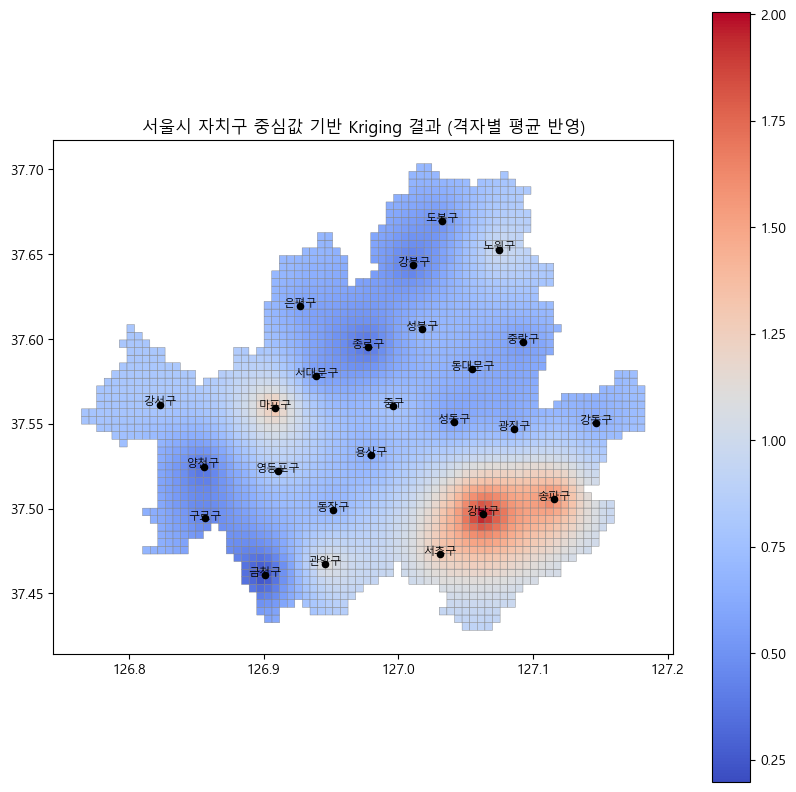

In [62]:
#%%
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from scipy.interpolate import griddata

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
seoul = gpd.read_file("서울시 상권분석서비스(영역-행정동).shp")

minx, miny, maxx, maxy = seoul.total_bounds
res = 500  # 500m
x_coords = np.arange(minx, maxx, res)
y_coords = np.arange(miny, maxy, res)
grid_polys = []
grid_centers = []
for x in x_coords:
    for y in y_coords:
        poly = Polygon([(x,y),(x+res,y),(x+res,y+res),(x,y+res)])
        grid_polys.append(poly)
        grid_centers.append((x+res/2, y+res/2))

grid = gpd.GeoDataFrame(geometry=grid_polys, crs=seoul.crs)
grid["cx"] = [c[0] for c in grid_centers]
grid["cy"] = [c[1] for c in grid_centers]

grid_in_seoul = grid[grid.intersects(seoul.unary_union)]

seoul_wgs = seoul.to_crs(epsg=4326)
grid_wgs = grid_in_seoul.to_crs(epsg=4326)

#grid_wgs.to_file("C:/Users/jeongmin/Downloads/seoul_grid_500m.shp", encoding='utf-8')

seoul_wgs["GU_CODE"] = seoul_wgs["ADSTRD_CD"].astype(str).str[:5]
seoul_wgs = seoul_wgs.dissolve(by="GU_CODE")
seoul_wgs["centroid"] = seoul_wgs.geometry.centroid
seoul_wgs["cx"] = seoul_wgs.centroid.x
seoul_wgs["cy"] = seoul_wgs.centroid.y
print(seoul_wgs.head) # 구 없음 

#%%
################################
#
#
#
# seoul_wgs["value"]에 보간하고 싶은 값이 들어가도록!!!
#
#
#
################################


seoul_wgs["value"] = np.random.randint(0, 100, len(seoul_wgs)) # 이따 바꾸기 
df_gu = seoul_wgs[["cx", "cy", "value"]].reset_index()
gu_name_map = {
    "11110": "종로구",
    "11140": "중구",
    "11170": "용산구",
    "11200": "성동구",
    "11215": "광진구",
    "11230": "동대문구",
    "11260": "중랑구",
    "11290": "성북구",
    "11305": "강북구",
    "11320": "도봉구",
    "11350": "노원구",
    "11380": "은평구",
    "11410": "서대문구",
    "11440": "마포구",
    "11470": "양천구",
    "11500": "강서구",
    "11530": "구로구",
    "11545": "금천구",
    "11560": "영등포구",
    "11590": "동작구",
    "11620": "관악구",
    "11650": "서초구",
    "11680": "강남구",
    "11710": "송파구",
    "11740": "강동구"
}

df_gu["GU_NM"] = df_gu["GU_CODE"].map(gu_name_map)
df_gu = df_gu[["GU_CODE", "GU_NM", "cx", "cy", "value"]]


# 구별 임의값 (예: 0~100 사이)
df.rename(columns={'자치구': 'GU_NM'}, inplace=True)

df_gu_1 = pd.merge(df_gu, df, how = 'left', on = 'GU_NM') 
print(df_gu_1.head())


points_gdf = gpd.GeoDataFrame(
    df_gu_1,
    geometry=gpd.points_from_xy(df_gu.cx, df_gu.cy),
    crs=grid_wgs.crs  # grid_wgs 좌표계와 동일하게 맞춤
)

grid_with_value = gpd.sjoin(
    grid_wgs,          # 왼쪽: 격자
    points_gdf[["GU_NM", "최종점수", "geometry"]],  # 오른쪽: 구 중심점
    how="left",
    predicate="contains"   # 중심점이 폴리곤 안에 있을 때만 매칭
)



# %%
from shapely.geometry import Point
from pykrige.ok import OrdinaryKriging

seoul_m = seoul.to_crs(epsg=5186)
points_m = points_gdf.to_crs(epsg=5186)
grid_m = grid_wgs.to_crs(epsg=5186)

x = points_m.geometry.x.values
y = points_m.geometry.y.values
v = points_m["최종점수"].values

OK = OrdinaryKriging(
    x, y, v,
    variogram_model="exponential",
    variogram_parameters={"sill": 1.0, "range": 8000, "nugget": 0.1},
    verbose=False, enable_plotting=False
)

minx, miny, maxx, maxy = seoul_m.total_bounds
res = 300  # 300m 해상도 보간 (격자보다 조금 더 촘촘하게)
gridx = np.arange(minx, maxx, res)
gridy = np.arange(miny, maxy, res)
z, ss = OK.execute("grid", gridx, gridy)
xx, yy = np.meshgrid(gridx, gridy)
zz = np.array(z)

# ───────────────────────────────
#  Kriging 결과를 포인트 GeoDataFrame으로 변환
# ───────────────────────────────
krig_points = gpd.GeoDataFrame(
    {"최종점수": zz.ravel()},
    geometry=[Point(xy) for xy in zip(xx.ravel(), yy.ravel())],
    crs=seoul_m.crs
)

# ───────────────────────────────
# 격자(grid_wgs)별 평균값 계산
# ───────────────────────────────
krig_points = krig_points[krig_points.within(seoul_m.unary_union)]
joined = gpd.sjoin(krig_points, grid_m, predicate="within")
grid_values = joined.groupby(joined.index_right)["최종점수"].mean()
grid_m["kriging_value"] = grid_values



grid_plot = grid_m.to_crs(epsg=4326)
points_plot = points_m.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))
grid_plot.plot(ax=ax, column="kriging_value", cmap="coolwarm", legend=True,
               edgecolor="gray", linewidth=0.3)
points_plot.plot(ax=ax, color="black", markersize=20)
for i, row in points_plot.iterrows():
    plt.text(row.cx, row.cy, row.GU_NM, fontsize=8, ha="center")
plt.title("서울시 자치구 중심값 기반 Kriging 결과 (격자별 평균 반영)")
plt.show()


# 수요

In [92]:
delivery = pd.read_csv('DELIVERY_202301_202412.csv', encoding='cp949')
delivery['건당평균금액'] = delivery['결제금액'] / delivery['결제건수']
delivery

,기준년월,구,결제건수,결제금액,건당평균금액
0,202301,강남구,3098268,56101912,18.107508
1,202301,강동구,679725,9695118,14.263295
2,202301,강북구,424058,6981782,16.464215
3,202301,강서구,1268539,18777012,14.802077
4,202301,관악구,1161992,16698028,14.370175
...,...,...,...,...,...
595,202412,용산구,931955,17794065,19.093266
596,202412,은평구,517539,7809990,15.090631
597,202412,종로구,1001510,18193560,18.166129
598,202412,중구,3397580,39068593,11.498947


In [93]:
df= pd.read_csv('수요지수변수.csv', encoding='cp949')
df['건당평균금액'] = df['결제금액'] / df['결제건수']
df

,연도,자치구,1인가구수,2030우울(%),2030스트레스(%),결제건수,결제금액,건당평균금액
0,2023,강남구,37895,25.3,73.8,3.313809e+06,5.580996e+07,16.841635
1,2023,강동구,25383,15.9,51.7,7.532025e+05,1.011451e+07,13.428670
2,2023,강북구,17250,16.0,61.0,4.600377e+05,6.909810e+06,15.020095
3,2023,강서구,51839,10.8,55.0,1.410072e+06,1.972500e+07,13.988650
4,2023,관악구,99467,22.2,68.9,1.270130e+06,1.707398e+07,13.442706
5,2023,광진구,41399,27.7,70.6,1.130522e+06,1.588681e+07,14.052629
6,2023,구로구,26911,13.1,54.0,7.389177e+05,9.974794e+06,13.499195
7,2023,금천구,25487,9.2,50.5,5.070882e+05,6.694727e+06,13.202294
8,2023,노원구,20673,13.4,71.5,7.146842e+05,1.031832e+07,14.437597
9,2023,도봉구,11372,19.4,55.5,3.252033e+05,4.495787e+06,13.824542


In [94]:
df.columns

Index(['연도', '자치구', '1인가구수', '2030우울(%)', '2030스트레스(%)', '결제건수', '결제금액',
       '건당평균금액'],
      dtype='object')

In [105]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# [STEP 1] 원본 데이터로 의미있는 지표를 먼저 계산합니다.
# '1인가구수'가 0일 경우를 대비하여 0으로 나누는 오류를 방지합니다.
df['1인가구당_평균금액'] = df['결제건수'] / df['1인가구수']

# 0으로 나눠서 생긴 무한대(inf) 값을 0으로 안전하게 처리합니다.
df.replace([np.inf, -np.inf], 0, inplace=True)
df['1인가구당_평균금액'].fillna(0, inplace=True) # 혹시 모를 NaN 값도 0으로 처리

# [STEP 2] 스케일링할 모든 변수를 하나의 리스트로 정의합니다.
cols_to_scale = ['2030우울(%)', '2030스트레스(%)', '1인가구당_평균금액']

# [STEP 3] 스케일러 객체를 생성하고, 선택한 열들을 한 번에 0~1 사이로 스케일링합니다.
# 이렇게 하면 모든 변수가 동일한 영향력의 출발선에 서게 됩니다.
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# [STEP 4] 스케일링이 완료된 변수들을 사용하여 최종 점수를 계산합니다.
# 이제 모든 변수가 0~1 사이의 값을 가지므로 공평하게 계산됩니다.
df['최종변수'] = df['2030우울(%)'] * df['2030스트레스(%)'] + df['1인가구당_평균금액']

# 결과 확인
print(df[['2030우울(%)', '2030스트레스(%)', '1인가구당_평균금액', '최종변수']].head())

    2030우울(%)  2030스트레스(%)  1인가구당_평균금액      최종변수
25   0.800000     0.539185    0.076138  0.507486
26   0.363158     0.031348    0.024962  0.036347
27   0.405263     0.902821    0.043422  0.409302
28   0.626316     1.000000    0.014220  0.640536
29   1.000000     0.884013    0.000000  0.884013


C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\3534416793.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['1인가구당_평균금액'] = df['결제건수'] / df['1인가구수']
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\3534416793.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace([np.inf, -np.inf], 0, inplace=True)
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\3534416793.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace 

In [106]:
df = df[-25:]
df

,연도,GU_NM,1인가구수,2030우울(%),2030스트레스(%),결제건수,결제금액,건당평균금액,최종변수,1인가구당 평균금액,1인가구당_평균금액
25,2024,강남구,0.303723,0.800000,0.539185,3.179103e+06,5.217020e+07,0.732497,0.507486,2.411729,0.076138
26,2024,강동구,0.170530,0.363158,0.031348,7.150585e+05,9.662439e+06,0.336539,0.036347,1.973481,0.024962
27,2024,강북구,0.065471,0.405263,0.902821,4.226974e+05,6.188164e+06,0.490533,0.409302,7.492419,0.043422
28,2024,강서구,0.457219,0.626316,1.000000,1.315025e+06,1.855272e+07,0.417911,0.640536,0.914027,0.014220
29,2024,관악구,1.000000,1.000000,0.884013,1.132835e+06,1.531606e+07,0.337540,0.884013,0.337540,0.000000
30,2024,광진구,0.341733,0.668421,0.912226,1.072834e+06,1.487114e+07,0.384195,0.626118,1.124257,0.016367
31,2024,구로구,0.175548,0.421053,0.451411,7.269925e+05,9.580246e+06,0.290777,0.214607,1.656397,0.024539
32,2024,금천구,0.169354,0.626316,0.689655,5.253588e+05,6.689217e+06,0.229932,0.448005,1.357695,0.016063
33,2024,노원구,0.107893,0.268421,0.310345,6.924451e+05,9.616704e+06,0.387816,0.126412,3.594447,0.043109
34,2024,도봉구,0.006081,0.968421,0.561129,3.079050e+05,4.273416e+06,0.386583,0.947167,63.570404,0.403758


C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\693586402.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_in_seoul = grid[grid.intersects(seoul.unary_union)]
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\693586402.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  seoul_wgs["centroid"] = seoul_wgs.geometry.centroid
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\693586402.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  seoul_wgs["cx"] = seoul_wgs.centroid.x
C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\693586402.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.

<bound method NDFrame.head of                                                   geometry ADSTRD_CD  \
GU_CODE                                                                
11110    POLYGON ((126.96883 37.56798, 126.96866 37.567...  11110515   
11140    POLYGON ((127.00421 37.55015, 127.00419 37.550...  11140520   
11170    POLYGON ((126.9824 37.50653, 126.981 37.50653,...  11170510   
11200    POLYGON ((127.03479 37.53583, 127.03473 37.535...  11200520   
11215    POLYGON ((127.07205 37.52342, 127.07035 37.523...  11215840   
11230    POLYGON ((127.05495 37.56516, 127.05485 37.565...  11230536   
11260    POLYGON ((127.09375 37.57057, 127.09337 37.570...  11260520   
11290    POLYGON ((127.02427 37.57909, 127.02425 37.579...  11290575   
11305    POLYGON ((127.02188 37.61233, 127.02181 37.612...  11305534   
11320    POLYGON ((127.03642 37.63686, 127.03607 37.636...  11320511   
11350    POLYGON ((127.06546 37.6149, 127.06515 37.6148...  11350560   
11380    POLYGON ((126.91277 37.58

C:\Users\Mycom\AppData\Local\Temp\ipykernel_18656\693586402.py:150: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  krig_points = krig_points[krig_points.within(seoul_m.unary_union)]


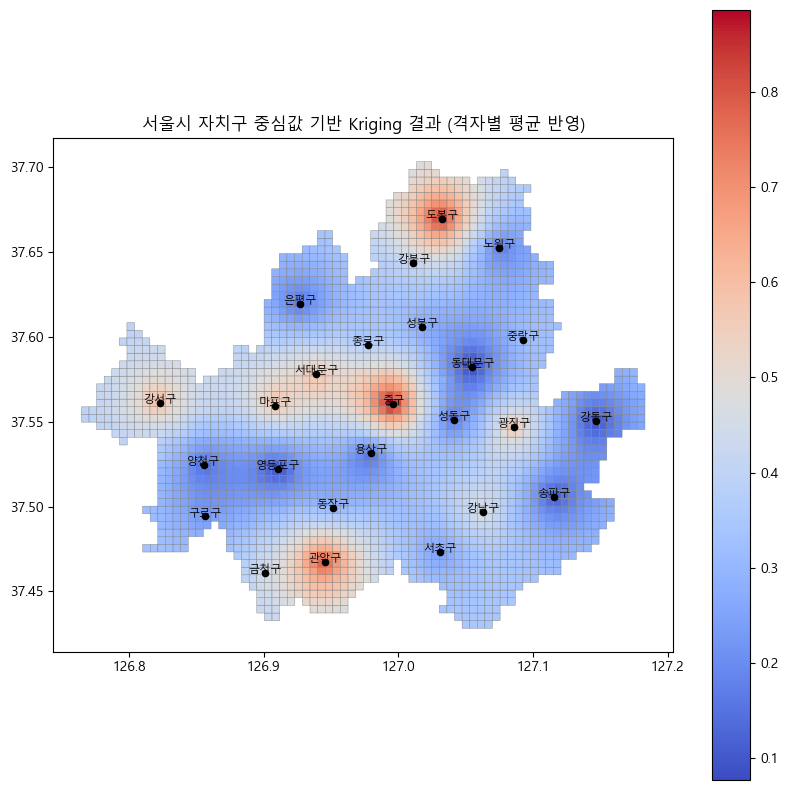

In [107]:
#%%
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from scipy.interpolate import griddata

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
seoul = gpd.read_file("서울시 상권분석서비스(영역-행정동).shp")

minx, miny, maxx, maxy = seoul.total_bounds
res = 500  # 500m
x_coords = np.arange(minx, maxx, res)
y_coords = np.arange(miny, maxy, res)
grid_polys = []
grid_centers = []
for x in x_coords:
    for y in y_coords:
        poly = Polygon([(x,y),(x+res,y),(x+res,y+res),(x,y+res)])
        grid_polys.append(poly)
        grid_centers.append((x+res/2, y+res/2))

grid = gpd.GeoDataFrame(geometry=grid_polys, crs=seoul.crs)
grid["cx"] = [c[0] for c in grid_centers]
grid["cy"] = [c[1] for c in grid_centers]

grid_in_seoul = grid[grid.intersects(seoul.unary_union)]

seoul_wgs = seoul.to_crs(epsg=4326)
grid_wgs = grid_in_seoul.to_crs(epsg=4326)

#grid_wgs.to_file("C:/Users/jeongmin/Downloads/seoul_grid_500m.shp", encoding='utf-8')

seoul_wgs["GU_CODE"] = seoul_wgs["ADSTRD_CD"].astype(str).str[:5]
seoul_wgs = seoul_wgs.dissolve(by="GU_CODE")
seoul_wgs["centroid"] = seoul_wgs.geometry.centroid
seoul_wgs["cx"] = seoul_wgs.centroid.x
seoul_wgs["cy"] = seoul_wgs.centroid.y
print(seoul_wgs.head) # 구 없음 

#%%
################################
#
#
#
# seoul_wgs["value"]에 보간하고 싶은 값이 들어가도록!!!
#
#
#
################################


seoul_wgs["value"] = np.random.randint(0, 100, len(seoul_wgs)) # 이따 바꾸기 
df_gu = seoul_wgs[["cx", "cy", "value"]].reset_index()
gu_name_map = {
    "11110": "종로구",
    "11140": "중구",
    "11170": "용산구",
    "11200": "성동구",
    "11215": "광진구",
    "11230": "동대문구",
    "11260": "중랑구",
    "11290": "성북구",
    "11305": "강북구",
    "11320": "도봉구",
    "11350": "노원구",
    "11380": "은평구",
    "11410": "서대문구",
    "11440": "마포구",
    "11470": "양천구",
    "11500": "강서구",
    "11530": "구로구",
    "11545": "금천구",
    "11560": "영등포구",
    "11590": "동작구",
    "11620": "관악구",
    "11650": "서초구",
    "11680": "강남구",
    "11710": "송파구",
    "11740": "강동구"
}

df_gu["GU_NM"] = df_gu["GU_CODE"].map(gu_name_map)
df_gu = df_gu[["GU_CODE", "GU_NM", "cx", "cy", "value"]]


# 구별 임의값 (예: 0~100 사이)
df.rename(columns={'자치구': 'GU_NM'}, inplace=True)

df_gu_1 = pd.merge(df_gu, df, how = 'left', on = 'GU_NM') 
print(df_gu_1.head())


points_gdf = gpd.GeoDataFrame(
    df_gu_1,
    geometry=gpd.points_from_xy(df_gu.cx, df_gu.cy),
    crs=grid_wgs.crs  # grid_wgs 좌표계와 동일하게 맞춤
)

grid_with_value = gpd.sjoin(
    grid_wgs,          # 왼쪽: 격자
    points_gdf[["GU_NM", "최종변수", "geometry"]],  # 오른쪽: 구 중심점
    how="left",
    predicate="contains"   # 중심점이 폴리곤 안에 있을 때만 매칭
)



# %%
from shapely.geometry import Point
from pykrige.ok import OrdinaryKriging

seoul_m = seoul.to_crs(epsg=5186)
points_m = points_gdf.to_crs(epsg=5186)
grid_m = grid_wgs.to_crs(epsg=5186)

x = points_m.geometry.x.values
y = points_m.geometry.y.values
v = points_m['최종변수'].values

OK = OrdinaryKriging(
    x, y, v,
    variogram_model="exponential",
    variogram_parameters={"sill": 1.0, "range": 8000, "nugget": 0.1},
    verbose=False, enable_plotting=False
)

minx, miny, maxx, maxy = seoul_m.total_bounds
res = 300  # 300m 해상도 보간 (격자보다 조금 더 촘촘하게)
gridx = np.arange(minx, maxx, res)
gridy = np.arange(miny, maxy, res)
z, ss = OK.execute("grid", gridx, gridy)
xx, yy = np.meshgrid(gridx, gridy)
zz = np.array(z)

# ───────────────────────────────
#  Kriging 결과를 포인트 GeoDataFrame으로 변환
# ───────────────────────────────
krig_points = gpd.GeoDataFrame(
    {"최종변수": zz.ravel()},
    geometry=[Point(xy) for xy in zip(xx.ravel(), yy.ravel())],
    crs=seoul_m.crs
)

# ───────────────────────────────
# 격자(grid_wgs)별 평균값 계산
# ───────────────────────────────
krig_points = krig_points[krig_points.within(seoul_m.unary_union)]
joined = gpd.sjoin(krig_points, grid_m, predicate="within")
grid_values = joined.groupby(joined.index_right)["최종변수"].mean()
grid_m["kriging_value"] = grid_values



grid_plot = grid_m.to_crs(epsg=4326)
points_plot = points_m.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))
grid_plot.plot(ax=ax, column="kriging_value", cmap="coolwarm", legend=True,
               edgecolor="gray", linewidth=0.3)
points_plot.plot(ax=ax, color="black", markersize=20)
for i, row in points_plot.iterrows():
    plt.text(row.cx, row.cy, row.GU_NM, fontsize=8, ha="center")
plt.title("서울시 자치구 중심값 기반 Kriging 결과 (격자별 평균 반영)")
plt.show()
